#### Import 

In [66]:
import shapefile

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize

import geopandas as gpd

import numpy as np
from mpl_toolkits.basemap import Basemap
from netCDF4 import *

from shapely.geometry import Point, shape  # shapely for geometric operations

In [3]:
# Open the shapefile using the pyshp library
sf = shapefile.Reader("gadm41_VNM_0/gadm41_VNM_1.shp")

# Get the shapefile records
records = sf.records()

# Try to print the first two records
print ((records[0:2]))

# Extract province names (I guess the record 4 is the name of the provinces)
province_names = [record[4] for record in records]

# Now check if we extract the correct records :))
print (province_names)

[Record #0: ['VNM.1_1', 'VNM', 'Vietnam', 'An Giang', 'An Giang', 'NA', 'Tỉnh', 'Province', 'NA', 'VN.AG', 'VN-44'], Record #1: ['VNM.7_1', 'VNM', 'Vietnam', 'Bà Rịa - Vũng Tàu', 'Ba Ria - Vung Tau', 'NA', 'Tỉnh', 'Province', 'NA', 'VN.BV', 'NA']]
['An Giang', 'Ba Ria - Vung Tau', 'Bac Giang', 'Bac Kan', 'Bac Lieu', 'Bac Ninh', 'Ben Tre', 'Binh Dinh', 'Binh Duong', 'Binh Phuoc', 'Binh Thuan', 'Ca Mau', 'Can Tho', 'Cao Bang', 'Da Nang', 'Dak Lak', 'Dak Nong', 'Dien Bien', 'Dong Nai', 'Dong Thap', 'Gia Lai', 'Ha Giang', 'Ha Nam', 'Ha Noi', 'Ha Tinh', 'Hai Duong', 'Hai Phong', 'Hau Giang', 'Ho Chi Minh', 'Hoa Binh', 'Hung Yen', 'Khanh Hoa', 'Kien Giang', 'Kon Tum', 'Lai Chau', 'Lam Dong', 'Lang Son', 'Lao Cai', 'Long An', 'Nam Dinh', 'Nghe An', 'Ninh Binh', 'Ninh Thuan', 'Phu Tho', 'Phu Yen', 'Quang Binh', 'Quang Nam', 'Quang Ngai', 'Quang Ninh', 'Quang Tri', 'Soc Trang', 'Son La', 'Tay Ninh', 'Thai Binh', 'Thai Nguyen', 'Thanh Hoa', 'Thua Thien Hue', 'Tien Giang', 'Tra Vinh', 'Tuyen Quan

#### Ex1
Using shapefile module

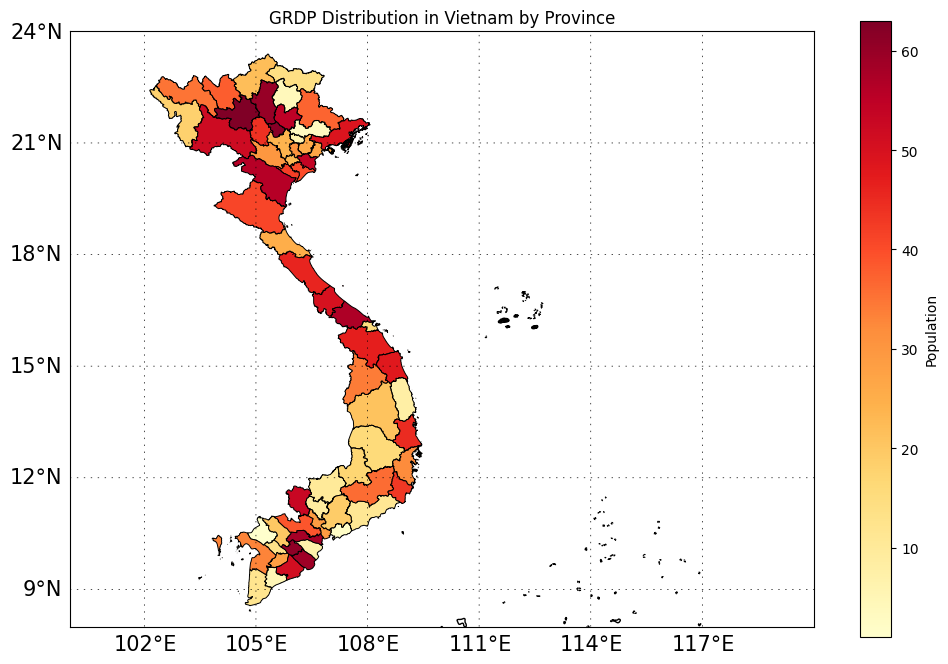

In [46]:
# Fake data about the GRDP :))
population = np.arange(1, 64, 1)

# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

# Add basemap
map1 = Basemap(projection='merc',llcrnrlon=100,llcrnrlat=8,
    urcrnrlon=120,urcrnrlat=24,resolution='l',epsg=4326)

parallels = np.arange(-90,150, 3) 	#lat
meridians = np.arange(102, 120, 3)
map1.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=15, zorder=12) # left, right, top or bottom
map1.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=15, zorder=12)

# Normalize the  data for coloring
norm = Normalize(vmin=min(population), vmax=max(population))

# Loop through the shapefile geometries and attributes to plot the map
for shapeRec, pop in zip(sf.shapeRecords(), population):
    shape = shapeRec.shape
    points = np.array(shape.points)
    parts = shape.parts # Ensuring that we have all polygon parts
    parts.append(len(points))

    # Add each part of the shape as a polygon to the map
    for i in range(len(parts) - 1):
        poly = Polygon(points[parts[i]:parts[i+1]], facecolor=plt.cm.YlOrRd(norm(pop)), edgecolor='k', lw=0.7)
        ax.add_patch(poly)

# Set the title and labels
ax.set_title('GRDP Distribution in Vietnam by Province')

# add islands
map1.readshapefile(r'haidao/haidao', 'haidao',
    linewidth=1, color='k')

ax.set_xlim(100, 120)
ax.set_ylim(8, 24)

# Create a colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Population')

# Show the map
plt.show()

#### Ex2
Using geopandas

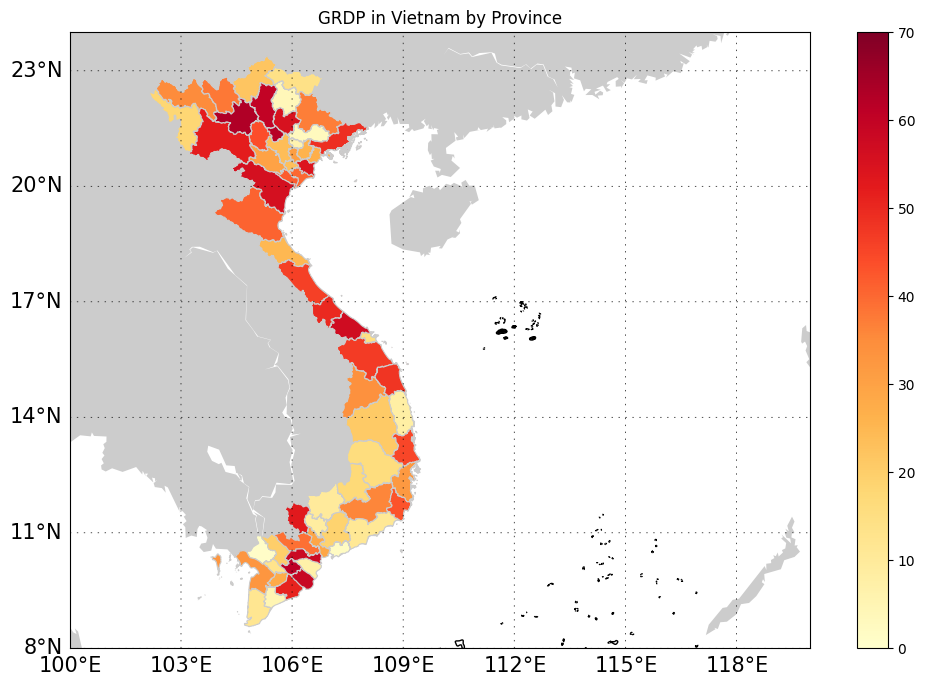

In [58]:
# Load a shapefile of Vietnam's provinces (replace with a real shapefile)
vietnam = gpd.read_file('gadm41_VNM_0/gadm41_VNM_1.shp')

# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

map2 = Basemap(projection='merc',llcrnrlon=100,llcrnrlat=8,
    urcrnrlon=120,urcrnrlat=24,
    llcrnrx=2,
    resolution='l',epsg=4326)

# add paralles, meridian
parallels = np.arange(8,24, 3) 	#lat
meridians = np.arange(100, 120, 3)
map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=15, zorder=12) # left, right, top or bottom
map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=15, zorder=12)

map2.fillcontinents()

# add islands
map2.readshapefile(r'haidao/haidao', 'haidao',
    linewidth=1, color='k')

# Plot the map with color-coded provinces
vietnam.plot(column=population, cmap='YlOrRd',vmin=0, vmax=70, linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# Set the title and labels
ax.set_title('GRDP in Vietnam by Province')

ax.set_xlim(100., 120)
ax.set_ylim(8, 24)
# Show the map
plt.show()

#### Ex3


In [67]:
# Open the shapefile using the pyshp library
sf = shapefile.Reader("gadm41_VNM_0/gadm41_VNM_1.shp")

#----#----#----#----#----#----#
# NOW WITH THE DATA
#----#----#----#----#----#----#

x_axis = np.arange(101, 110, 0.05) # longtitude
y_axis = np.arange(8, 24, 0.05) # latitude

x_axis, y_axis = np.meshgrid(x_axis, y_axis)
np.random.seed(seed=180793)

data = np.random.randint(1, 1000, size = (np.size(x_axis,0), np.size(x_axis, 1)))

In [70]:
# Array to contain mean of each province
mean_container = np.zeros((63,1))

# Iterate over the shapes in the shapefile
for idx, shapeRec in enumerate(sf.shapeRecords()):
    polygon = shape(shapeRec.shape)  # Convert the shape to a Shapely polygon
    tmp_array = np.array([]) # Temp array to hold data point inside a shape polygon

    # Check if the pixel point is inside the polygon
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            pixel_coord = (x_axis[row, col], y_axis[row, col])
            pixel_point = Point(pixel_coord)

            if polygon.contains(pixel_point):
                tmp_array = np.append(tmp_array, data[row, col])
            else:
                pass
    
    mean_container[idx] = tmp_array.mean()

mean_container = np.squeeze(mean_container)

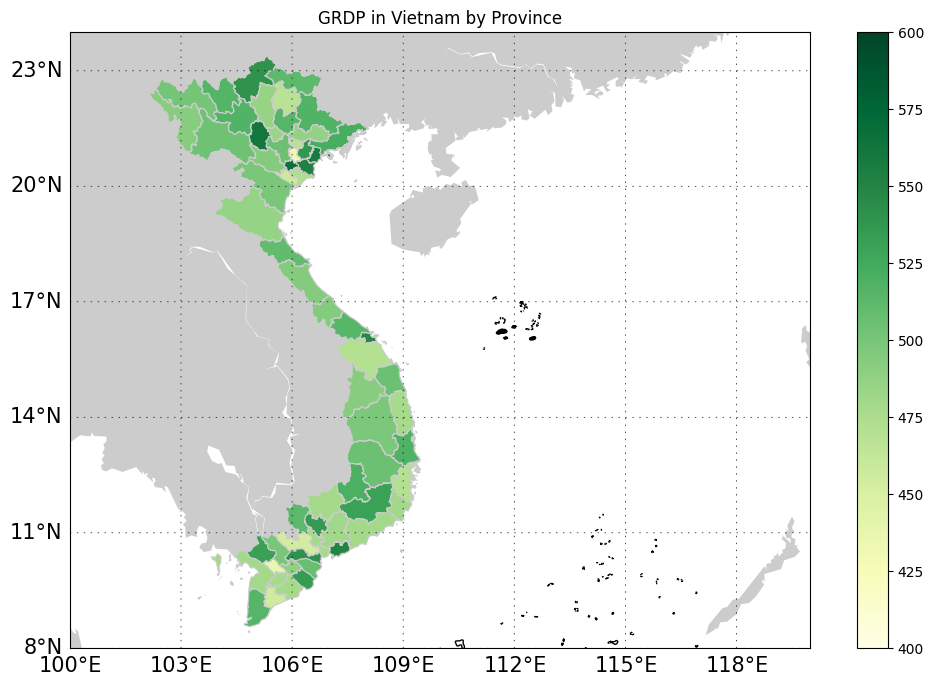

In [79]:
# Load a shapefile of Vietnam's provinces (replace with a real shapefile)
vietnam = gpd.read_file('gadm41_VNM_0/gadm41_VNM_1.shp')

# Create a figure and axis
fig, ax = plt.subplots(1, figsize=(12, 8))

map2 = Basemap(projection='merc',llcrnrlon=100,llcrnrlat=8,
    urcrnrlon=120,urcrnrlat=24,
    llcrnrx=2,
    resolution='l',epsg=4326)

# add paralles, meridian
parallels = np.arange(8,24, 3) 	#lat
meridians = np.arange(100, 120, 3)
map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=15, zorder=12) # left, right, top or bottom
map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=15, zorder=12)

map2.fillcontinents()

# add islands
map2.readshapefile(r'haidao/haidao', 'haidao',
    linewidth=1, color='k')

# Plot the map with color-coded provinces
vietnam.plot(column=mean_container, cmap='YlGn',vmin=400, vmax=600, linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# Set the title and labels
ax.set_title('GRDP in Vietnam by Province')

ax.set_xlim(100., 120)
ax.set_ylim(8, 24)
# Show the map
plt.show()